# Working with H3 in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/01_h3.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/01_h3.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/01_h3.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://jupyterlite.gishub.vn/lab/index.html?path=notebooks/vgrid/01_h3.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

## Install vgrid

In [ ]:
# %pip install vgrid --upgrade

## latlon2h3

In [2]:
from vgrid.conversion.latlon2dggs import latlon2h3

lat = 10.775276
lon = 106.706797
res = 10
h3_id = latlon2h3(lat, lon, res)
h3_id

'8a65b56628e7fff'

### H3 to Polygon

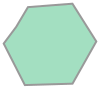

In [2]:
from vgrid.conversion.dggs2geo.h32geo import h32geo
h3_id = '819b7ffffffffff'
h3_geo = h32geo(h3_id,fix_antimeridian = 'shift')
h3_geo

### H3 to GeoJSON        

In [3]:
from vgrid.conversion.dggs2geo.h32geo import h32geojson

h3_geojson = h32geojson("8a283082a677fff")
# h3_geojson

### Vector to H3

(Multi)Point to H3

Processing features: 100%|██████████| 12/12 [00:00<00:00, 2354.37it/s]


<Axes: >

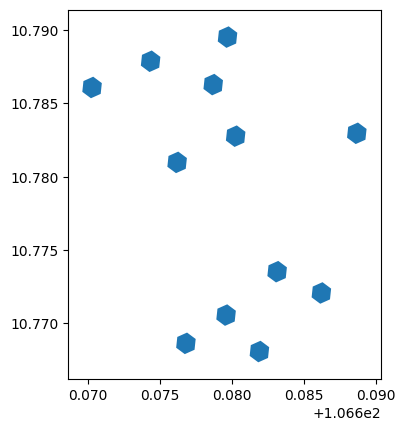

In [1]:
### Point to H3
from vgrid.conversion.vector2dggs.vector2h3 import vector2h3
import geopandas as gpd

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/point.geojson"
)

gdf = gpd.read_file(file_path)

point_to_h3 = vector2h3(
    gdf,
    topology=True,
    output_format="gpd",
)
point_to_h3.plot()

#### (Multi)Polyline to H3


Processing features: 100%|██████████| 7/7 [00:00<00:00, 2436.93it/s]


<Axes: >

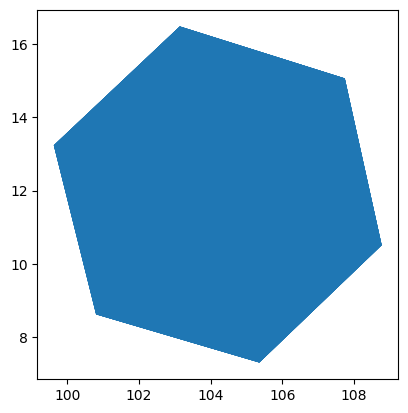

In [12]:
### Polyline to H3
from vgrid.conversion.vector2dggs.vector2h3 import vector2h3
import geopandas as gpd

# file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/hcmc_bus.geojson"
file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polyline.geojson"


gdf = gpd.read_file(file_path)

polyline_to_h3 = vector2h3(
    gdf,
    resolution=1,
    output_format="gpd",
)
polyline_to_h3.plot()

#### (Multi)Polygon to H3


Processing features: 100%|██████████| 4/4 [00:00<00:00,  6.99it/s]


<Axes: >

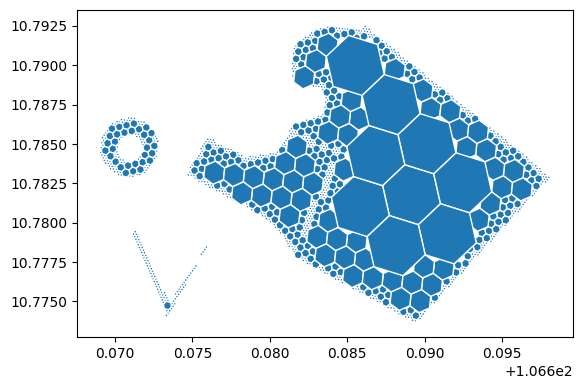

In [4]:
### Polygon to H3
from vgrid.conversion.vector2dggs.vector2h3 import vector2h3
import geopandas as gpd

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon.geojson"
)
# file_path = "antimeridian.geojson"

gdf = gpd.read_file(file_path)

vector_to_h3 = vector2h3(
    gdf,
    resolution=12,
    compact=True,
    predicate="centroid_within",
    output_format="gpd",
    # fix_antimeridian = 'shift_west'
)
vector_to_h3.plot(edgecolor="white")

### H3 Compact

<Axes: >

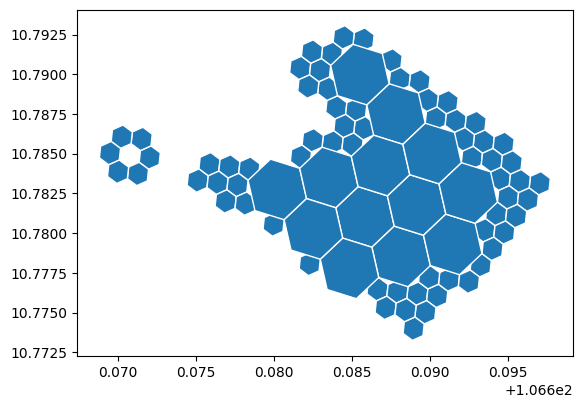

In [9]:
from vgrid.conversion.dggscompact.h3compact import h3compact

h3_compacted = h3compact(vector_to_h3, output_format="gpd")
h3_compacted.plot(edgecolor="white")

### H3 Expand

<Axes: >

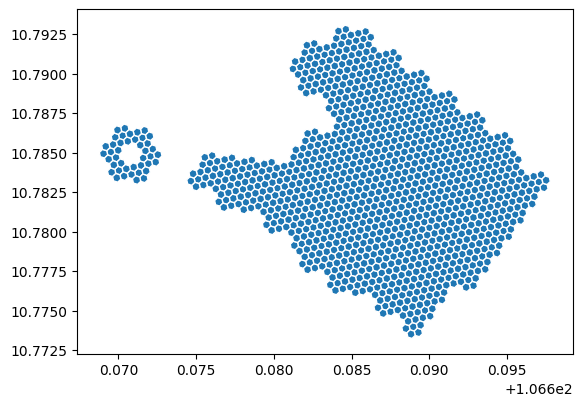

In [10]:
from vgrid.conversion.dggscompact.h3compact import h3expand

h3_expanded = h3expand(h3_compacted, resolution=11, output_format="gpd")
h3_expanded.plot(edgecolor="white")

### H3 Binning

Generating H3 DGGS: 100%|██████████| 3440/3440 [00:00<00:00, 6911.39it/s]


<Axes: >

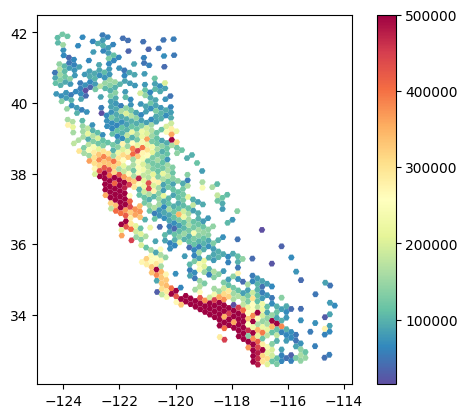

In [8]:
from vgrid.binning.h3bin import h3bin

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv"
)
numeric_col = "median_house_value"
stats = "max"

h3_bin = h3bin(
    file_path,
    resolution=5,
    stats=stats,
    numeric_col=numeric_col,
    # category_col="category",
    output_format="gpd",
)
h3_bin.plot(
    column=f"{numeric_col}_{stats}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### H3 Resampling

Area-weighted resampling: 100%|██████████| 5743/5743 [00:00<00:00, 6064.66 cells/s]


<Axes: >

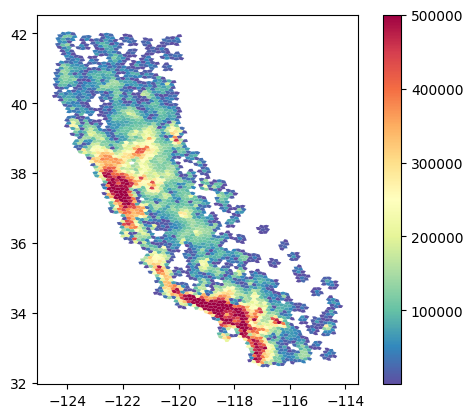

In [9]:
from vgrid.conversion.dggsresample import dggsresample

h3_resample = dggsresample(
    source_dggs=h3_bin,
    dggs_from="h3",
    dggs_to="a5",
    resolution=None,  # or -1: auto nearest resolution
    dggs_col="h3",
    resample_col=f"{numeric_col}_{stats}",  # column on h3_bin with numbers
    method="area_weighted",
    fix_antimeridian=None,
    split_antimeridian=False,
)
h3_resample.plot(
    column=f"{numeric_col}_{stats}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Raster to H3

#### Download and open raster

rgb.tif already exists. Skip downloading. Set overwrite=True to overwrite.
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 240, 'height': 147, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(2.6640125000199077e-06, 0.0, 106.708118755,
       0.0, -2.6640136054383103e-06, 10.812568272)}


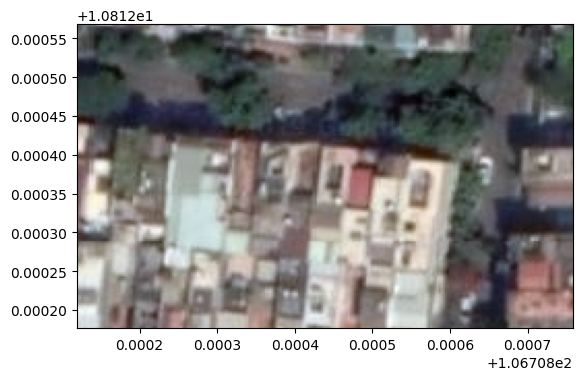

<Axes: >

In [10]:
from vgrid.utils.io import download_file
import rasterio
from rasterio.plot import show

raster_url = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/raster/rgb.tif"  # SRTM.tif
raster_file = download_file(raster_url)
src = rasterio.open(raster_file, "r")
print(src.meta)
show(src)

#### Convert raster to H3

In [11]:
# %pip install folium

In [12]:
from vgrid.conversion.raster2dggs.raster2h3 import raster2h3

### Convert to H3
raster_to_h3 = raster2h3(
    raster_file,
    resolution=15,
    method="nearest",  # nearest, binning
    stats="mean",
    output_format="gpd",
)
raster_to_h3.head()

# # Visualize the output
import folium

m = folium.Map(tiles="CartoDB positron", max_zoom=28)

h3_layer = folium.GeoJson(
    raster_to_h3,
    style_function=lambda x: {
        "fillColor": f"rgb({x['properties']['band_1']}, {x['properties']['band_2']}, {x['properties']['band_3']})",
        "fillOpacity": 1,
        "color": "black",
        "weight": 0.5,
    },
    popup=folium.GeoJsonPopup(
        fields=["h3", "resolution", "band_1", "band_2", "band_3", "cell_area"],
        aliases=["H3 ID", "Resolution", "Band 1", "Band 2", "Band 3", "Area (m²)"],
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
        """,
    ),
).add_to(m)

m.fit_bounds(h3_layer.get_bounds())

# Display the map
m

Method: nearest_neighbour


Reading raster pixel centers: 100%|██████████| 14/14 [00:00<00:00, 16.94 block/s]


### H3 Generator

Generating H3 DGGS: 100%|██████████| 842/842 [00:00<00:00, 5875.51 cells/s]


<Axes: >

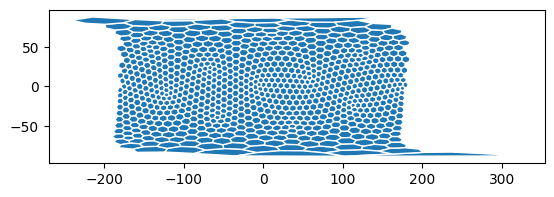

In [2]:
from vgrid.generator.h3grid import h3grid

h3_grid = h3grid(
    resolution=1,
    output_format="gpd",
    fix_antimeridian="shift_balanced",  # 'shift_west', 'shift_east', 'shift_balanced', 'split'
    # bbox=[106.699007, 10.762811, 106.717674, 10.778649],
    compact=False,
)
h3_grid.plot(edgecolor="white")

### H3 Inspect

In [3]:
from vgrid.stats.h3stats import h3inspect

resolution = 3
h3_inspect = h3inspect(resolution)
h3_inspect.head()

Generating H3 DGGS: 100%|██████████| 41162/41162 [00:02<00:00, 15159.12 cells/s]


,h3,resolution,center_lat,center_lon,avg_edge_len,cell_area,cell_perimeter,geometry,crossed,is_pentagon,norm_area,ipq,zsc,cvh
0,830000fffffffff,3,79.243774,38.024416,68843.990170,1.229263e+10,413063.941020,"POLYGON ((38.40265 78.62862, 40.9926 78.94864,...",False,False,0.992008,0.905357,0.951491,1.0
1,830001fffffffff,3,80.118133,34.269779,68959.671785,1.233470e+10,413758.030713,"POLYGON ((34.90645 79.50578, 37.59652 79.85885...",False,False,0.995403,0.905410,0.951519,1.0
2,830002fffffffff,3,79.248915,43.752678,69357.427250,1.247975e+10,416144.563503,"POLYGON ((43.80951 78.62667, 46.57082 78.89905...",False,False,1.007109,0.905581,0.951609,1.0
3,830003fffffffff,3,80.192303,40.496153,69494.752859,1.253001e+10,416968.517157,"POLYGON ((40.75903 79.56831, 43.68502 79.87171...",False,False,1.011165,0.905638,0.951639,1.0
4,830004fffffffff,3,78.291383,35.976646,68171.344007,1.204928e+10,409028.064042,"POLYGON ((36.42872 77.68575, 38.74177 78.01773...",False,False,0.972370,0.905034,0.951321,1.0


### H3 Normalized Area Histogram

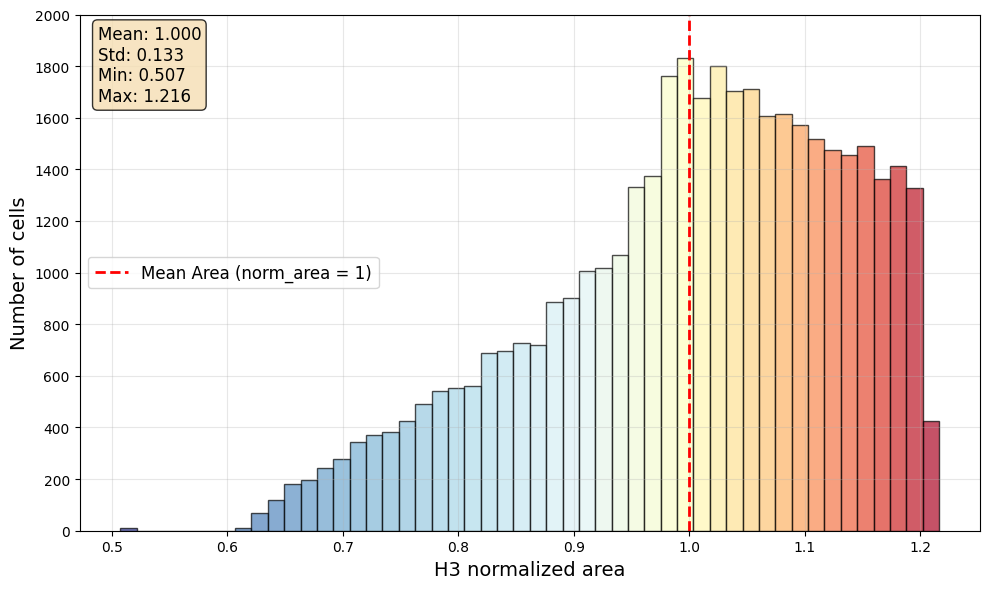

In [4]:
from vgrid.stats.h3stats import h3_norm_area_hist

h3_norm_area_hist(h3_inspect)

### Distribution of H3 Area Distortions

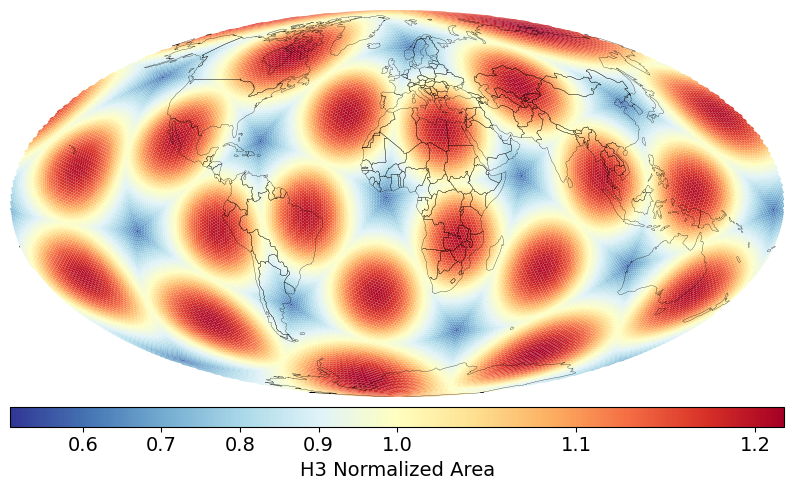

In [5]:
from vgrid.stats.h3stats import h3_norm_area

h3_norm_area(h3_inspect)

### H3 IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is (0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.


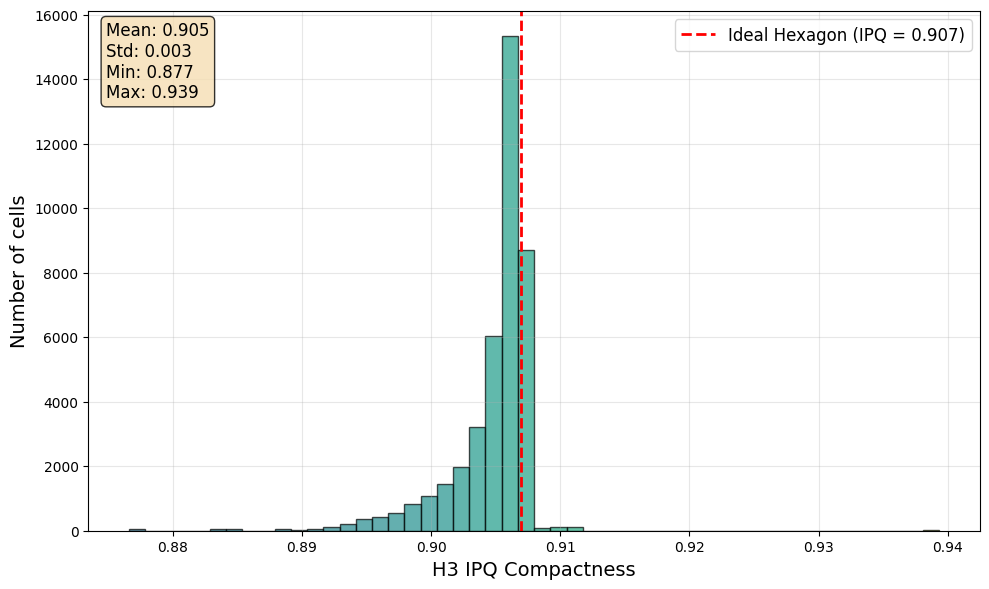

In [6]:
from vgrid.stats.h3stats import h3_compactness_ipq_hist

h3_compactness_ipq_hist(h3_inspect)

### Distribution of H3 IPQ Compactness

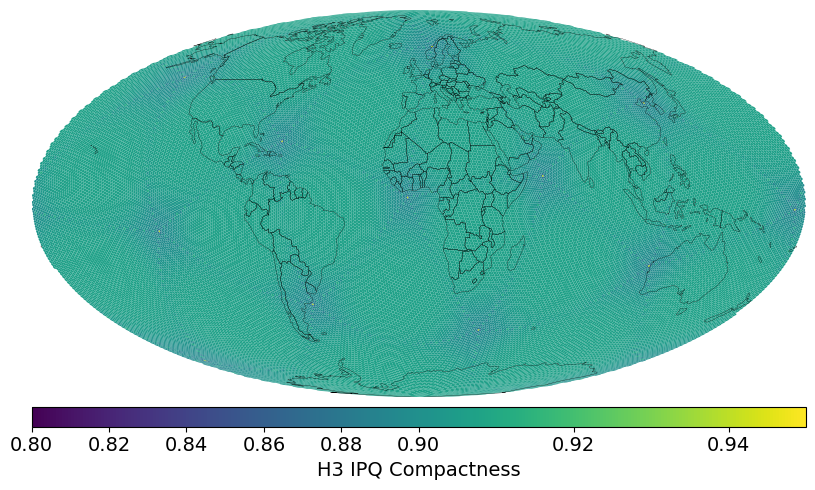

In [7]:
from vgrid.stats.h3stats import h3_compactness_ipq

h3_compactness_ipq(h3_inspect)

### H3 Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the convex hull compactness metric is (0,1]. 

As shapes become more concave, their convex hull compactness decreases toward 0.

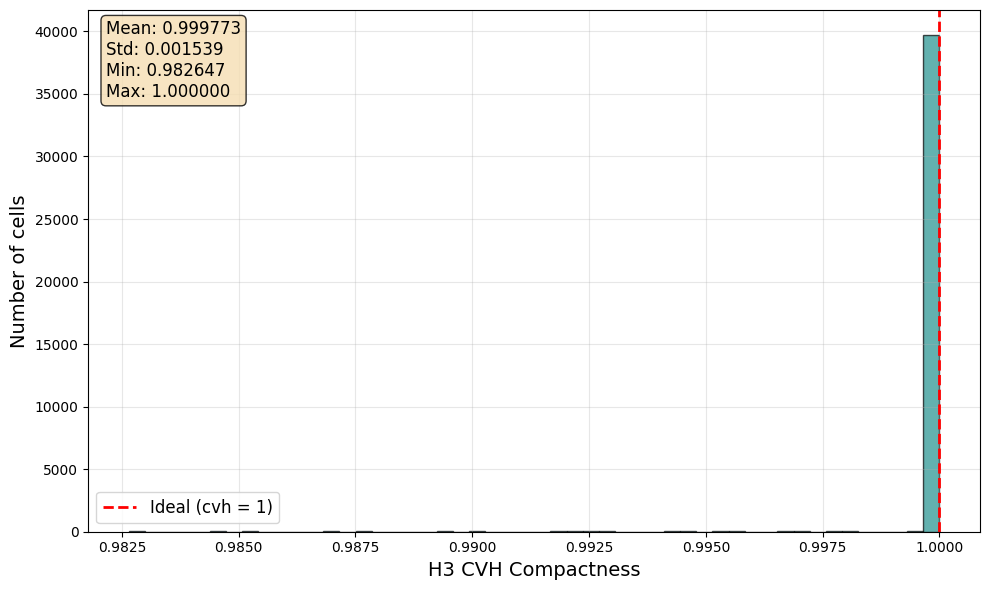

In [9]:
from vgrid.stats.h3stats import h3_compactness_cvh_hist

h3_compactness_cvh_hist(h3_inspect)

### Distribution of H3 Convex hull Compactness

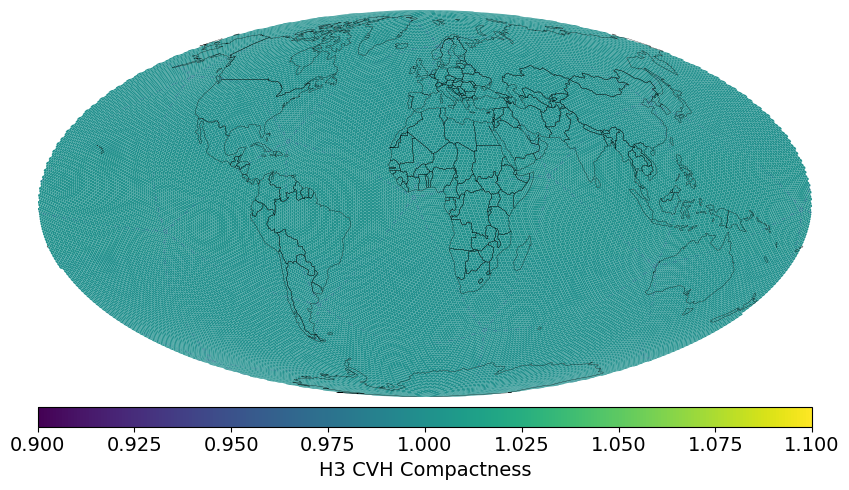

In [8]:
from vgrid.stats.h3stats import h3_compactness_cvh

h3_compactness_cvh(h3_inspect)

### H3 Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [22]:
from vgrid.stats.h3stats import h3stats

h3_stats = h3stats("m")
h3_stats

,resolution,number_of_cells,avg_edge_len_m,avg_area_m,min_area_m,max_area_m,max_min_ratio,cls_m
0,0,122,1.281256e+06,4.357449e+12,2.562182e+12,4.977807e+12,1.942800,2.358802e+06
1,1,842,4.830568e+05,6.097884e+11,3.284346e+11,7.294869e+11,2.221102,8.813151e+05
2,2,5882,1.825130e+05,8.680178e+10,4.493090e+10,1.045998e+11,2.328015,3.324541e+05
3,3,41162,6.897922e+04,1.239343e+10,6.315472e+09,1.495077e+10,2.367325,1.256182e+05
4,4,288122,2.607176e+04,1.770348e+09,8.965824e+08,2.135987e+09,2.382366,4.747714e+04
5,5,2016842,9.854091e+03,2.529039e+08,1.277856e+08,3.051443e+08,2.387940,1.794456e+04
6,6,14117882,3.724533e+03,3.612906e+07,1.823875e+07,4.359211e+07,2.390082,6.782400e+03
7,7,98825162,1.406476e+03,5.161293e+06,2.604669e+06,6.227446e+06,2.390878,2.563506e+03
8,8,691776122,5.314140e+02,7.373276e+05,3.720480e+05,8.896352e+05,2.391184,9.689142e+02
9,9,4842432842,2.007861e+02,1.053325e+05,5.314719e+04,1.270907e+05,2.391297,3.662151e+02
